In [1]:
import os
import torch

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torchvision as tv
import torchvision.transforms as tr

import torchaudio as ta
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchsummary import summary

from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
sns.set(style='ticks')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')  # for summary
device

device(type='cpu')

# DATA

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = np.load('/content/drive/My Drive/Data.npz')

data["train_x"][0]
np.shape(data["train_x"][0])

(80000, 1)

In [5]:
audio_file = data["train_x"][0]

m = torch.tensor(audio_file)
m = torch.reshape(m, (-1,))
print(m.shape)
tr_data_test = (ta.transforms.MelSpectrogram(sample_rate=22050, n_mels=128)(m))
print(tr_data_test.shape)


torch.Size([80000])
torch.Size([128, 401])


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [6]:
data_vx = data["valid_x"]
data_tx = data["train_x"]

data_vy = data["valid_y"]
data_ty = data["train_y"]
print(data_vx.shape)
print(data_tx.shape)

(400, 80000, 1)
(1200, 80000, 1)


In [75]:
transform = ta.transforms.MelSpectrogram(
    n_fft=2048,
    hop_length=512,
    n_mels=128)

new_vx = []
for el in data_vx:
  el = torch.tensor(el)
  el = torch.reshape(el, (-1,))
  el = transform(el)
  new_vx.append([el])

print(np.array(new_vx).shape)

(400, 1, 128, 157)


In [8]:
transform = ta.transforms.MelSpectrogram(
    n_fft=2048,
    hop_length=512,
    n_mels=128)

new_tx = []
for el in data_tx:
  el = torch.tensor(el)
  el = torch.reshape(el, (-1,))
  el = transform(el)
  new_tx.append([el])

print(np.array(new_tx).shape)

(1200, 1, 128, 157)


In [9]:
train_x = data["train_x"]
train_y = data["train_y"]

decode_massive = []
decode_set = []
decode_dict = {}

for i in train_y:
    res = ""
    flag = False
    for j in str(i):
        if j.isupper():
            flag = True
        if flag:
            res += j
    decode_massive.append(res)
    if not(res in decode_set):
        decode_set.append(res)

for i in range(len(decode_set)):
    decode_dict[decode_set[i]] = i

decode_dict = dict(sorted(decode_dict.items(), key=lambda x: len(x[0]), reverse=True))
decode_dict

{'Gliese_163_c': 0,
 'HD_216520_c': 1,
 'Kepler-174d': 4,
 'Kepler-186f': 5,
 'HIP_38594_b': 7,
 'Gliese_12_b': 10,
 'Kepler-296f': 11,
 'Kepler-296e': 12,
 'Kepler-155c': 15,
 'Kepler-283c': 19,
 'Kepler-62f': 6,
 'Kepler-22b': 8,
 'HD_20794_d': 9,
 'Kepler-62e': 14,
 'Cancri_Bc': 18,
 'K2-288Bb': 17,
 'K2-332b': 2,
 'K2-155d': 3,
 'Gliese_': 16,
 'K2-72e': 13}

In [66]:
len(decode_dict)

20

In [10]:
names_decode_ty = []
for el in data_ty:
  for name in decode_dict.keys():
     if name in el:
      names_decode_ty.append([decode_dict[name]])
      break

print(np.array(names_decode_ty).shape)

(1200, 1)


In [11]:
names_decode_vy = []
for el in data_vy:
  for name in decode_dict.keys():
    if name in el:
      names_decode_vy.append([decode_dict[name]])
      break

print(np.array(names_decode_vy).shape)

(400, 1)


In [24]:
def set_name(arr: list, y: list):
    result = list()
    for id, name in y:
        result.append([arr[int(id)][0], name[0]])
    return result

train_list = set_name(new_tx, enumerate(names_decode_ty))
valid_list = set_name(new_vx, enumerate(names_decode_vy))

train_list[:2][0]

[tensor([[9.4077e-14, 6.6002e-14, 1.7157e-14,  ..., 1.4470e-13, 1.7318e-13,
          5.1746e-14],
         [1.9179e-13, 7.8163e-14, 8.5287e-15,  ..., 8.5370e-14, 1.3911e-13,
          1.9683e-14],
         [3.6599e-14, 6.0383e-14, 3.2822e-14,  ..., 4.6521e-14, 5.1786e-14,
          7.4079e-15],
         ...,
         [3.2280e-13, 4.4569e-13, 5.4795e-13,  ..., 1.3431e-12, 1.0632e-12,
          4.3570e-13],
         [5.9339e-13, 6.0687e-13, 5.9384e-13,  ..., 8.2656e-13, 9.9058e-13,
          9.3375e-13],
         [8.9484e-09, 9.3560e-09, 9.9336e-09,  ..., 7.7220e-09, 8.2350e-09,
          8.7262e-09]]),
 0]

In [25]:
train_loader = DataLoader(train_list, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_list, batch_size=32, shuffle=True)

# FUNC TOOLS

In [77]:
history = {"acc": [], "pre": [], "rec": [], "f1": [], "minval": []}
models = []

In [60]:
def train(model: nn.Module, data_loader: DataLoader, optimizer, loss_fn, epoch: int):
    model.train()

    total_loss = 0

    for x, y in tqdm(data_loader, desc=f"Epoch №{epoch + 1}"):
        x = x.to(device)
        optimizer.zero_grad()
        output = model(x)
        output = torch.reshape(output,(-1,)).to(torch.float )
        loss = loss_fn(output, y.to(device).to(torch.float))
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        del x
        torch.cuda.empty_cache()
    return total_loss / len(data_loader)


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn):
    model.eval()

    total_loss = 0
    accuracy_list = []
    precision_list = []
    recall_list = []
    f1_list = []

    for x, y in tqdm(data_loader, desc=f"———————>"):
        x = x.to(device)
        output = model(x)
        output_val = torch.argmax(output, dim=1).cpu()
        output = torch.reshape(output,(-1,)).to(torch.float )
        accuracy_list.append(accuracy_score(y, output_val))
        precision_list.append(precision_score(y, output_val, average='macro', zero_division=0.0))
        recall_list.append(recall_score(y, output_val, average='macro', zero_division=0.0))
        f1_list.append(f1_score(y, output_val, average='macro', zero_division=0.0))
        loss = loss_fn(output, y.to(device).to(torch.float))
        total_loss += loss.item()
        del x
        torch.cuda.empty_cache()
    acc = np.mean(accuracy_list)
    pre = np.mean(precision_list)
    rec = np.mean(recall_list)
    f1 = np.mean(f1_list)
    print(f"F1 in epoch: {f1}.")
    return (total_loss / len(data_loader)), acc, pre, rec, f1


def plot_stats(
    train_loss: list,
    valid_loss: list,
    title: str
):
    plt.figure(figsize=(10, 4))

    plt.title(title + "'s loss")

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Real loss')

    plt.legend()

    plt.ylabel("Loss")
    plt.xlabel("Epoch")

    plt.show()


def simple_stats(data, title):
    plt.figure(figsize=(10, 4))

    plt.title(title)
    acc, pre, rec, f1 = data
    plt.plot(acc, label='Accuracy')
    plt.plot(pre, label='Precision')
    plt.plot(rec, label='Recall')
    plt.plot(f1, label='F1')

    plt.ylabel("Params")
    plt.xlabel("Epoch")

    plt.legend()

    plt.show()


def fit(model, train_loader, valid_loader, optimizer, loss_fn, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    accuracy_history = []
    recall_history = []
    pre_history = []
    f1_history = []

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn, epoch)
        valid_loss, acc, pre, rec, f1 = evaluate(model, valid_loader, loss_fn)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        accuracy_history.append(acc)
        recall_history.append(rec)
        pre_history.append(pre)
        f1_history.append(f1)
    plot_stats(train_loss_history, valid_loss_history, title)
    print(train_loss_history, valid_loss_history)
    simple_stats((accuracy_history, pre_history, recall_history, f1_history), f"{title}'s metrics")
    print(f"Total:\nAccuracy: {accuracy_history[-1]}, Precision: {pre_history[-1]}, Recall: {recall_history[-1]}, F1: {f1_history[-1]}")
    history["acc"].append(accuracy_history[-1])
    history["rec"].append(recall_history[-1])
    history["pre"].append(pre_history[-1])
    history["f1"].append(f1_history[-1])
    history["minval"].append(min(valid_loss_history))
    models.append(title)


@torch.inference_mode()
def test(model: nn.Module, data_loader: DataLoader):
    model.eval()
    test_preds = torch.LongTensor()

    for x in tqdm(data_loader, desc=f"———————>"):
        x = x.to(device)
        output = model(x)
        output_val = torch.argmax(output, dim=1).cpu()  # for numpy
        test_preds = torch.cat((test_preds, output_val), dim=0)
        del x
        torch.cuda.empty_cache()
    return test_preds

# NN

## FC

In [48]:
class FullyConnected_Net(nn.Module):
    def __init__(self):
        super(FullyConnected_Net, self).__init__()
        self.fc1 = nn.Linear(128 * 157, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(p=0.2)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.view(-1, 128 * 157)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

In [76]:
fc_net = FullyConnected_Net().to(device)
summary(fc_net, (1, 128, 157))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]       2,572,416
       BatchNorm1d-2                  [-1, 128]             256
           Dropout-3                  [-1, 128]               0
            Linear-4                   [-1, 64]           8,256
       BatchNorm1d-5                   [-1, 64]             128
           Dropout-6                   [-1, 64]               0
            Linear-7                    [-1, 1]              65
Total params: 2,581,121
Trainable params: 2,581,121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.08
Forward/backward pass size (MB): 0.00
Params size (MB): 9.85
Estimated Total Size (MB): 9.93
----------------------------------------------------------------


———————>: 100%|██████████| 13/13 [00:00<00:00, 41.87it/s]


F1 in epoch: 0.0070661972911107845.


———————>: 100%|██████████| 13/13 [00:00<00:00, 72.29it/s]


F1 in epoch: 0.0073669466024788716.


———————>: 100%|██████████| 13/13 [00:00<00:00, 70.74it/s]


...

F1 in epoch: 0.006261889665251009.


———————>: 100%|██████████| 13/13 [00:00<00:00, 46.28it/s]


F1 in epoch: 0.0063064386593798365.


———————>: 100%|██████████| 13/13 [00:00<00:00, 76.28it/s]


F1 in epoch: 0.006851024661777922.


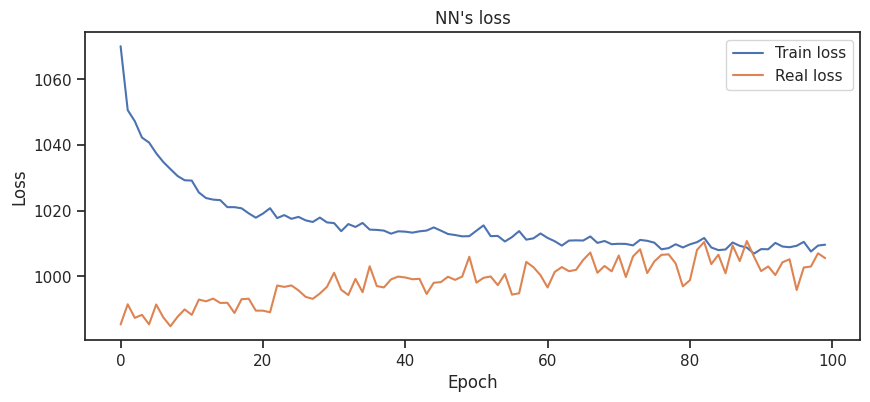

[1070.1011087517988, 1050.657799971731, 1047.2530951248973, 1042.305264924702, 1040.780830784848, 1037.5372667814556, 1034.8612662867497, 1032.7072384482935, 1030.6084096808183, 1029.2995228014495, 1029.196962055407, 1025.5735056023848, 1023.8848122044614, 1023.4065102025082, 1023.2481046977796, 1021.115069740697, 1021.107700548674, 1020.760911640368, 1019.2240745142886, 1017.9027292351974, 1019.1526384855572, 1020.7893636603104, 1017.7809175190173, 1018.6925048828125, 1017.5623835513467, 1018.1493425871197, 1017.094516954924, 1016.5958806088096, 1017.9391768606085, 1016.4644116853412, 1016.2583465576172, 1013.8024926436575, 1015.9620947586862, 1015.0808635510897, 1016.3060800652755, 1014.2728239360608, 1014.1863323010897, 1013.9678023488898, 1013.0292286119962, 1013.7531529476768, 1013.6507022255346, 1013.3423092490748, 1013.7539383737665, 1013.9809690776624, 1014.9406890869141, 1013.9630962171053, 1012.9409276058799, 1012.6256513093647, 1012.218166953639, 1012.2855417351974, 1013.945

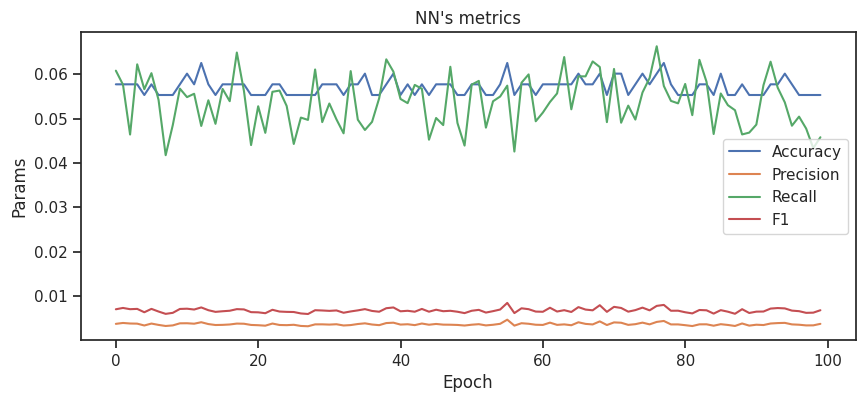

Total:
Accuracy: 0.055288461538461536, Precision: 0.003788382031806805, Recall: 0.04578195183398803, F1: 0.006851024661777922


In [78]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(fc_net.parameters(), lr=0.001)
fit(fc_net, train_loader, valid_loader, optimizer, loss_fn, 100, "NN")

# VGG16


In [98]:
class Easy_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model_stack = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=7, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2),  #24x24 -> 12x12

            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=7, padding=1),  #12x12 -> 8x8
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2), # 8x8 -> 4x4
            nn.Flatten(),
            nn.Linear(in_features=16704, out_features=256),
            # nn.Dropout(p=0.3),
            nn.LeakyReLU(),
            nn.Linear(in_features=256, out_features=128),
            # nn.Dropout(p=0.3),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=10),
        )

    def forward(self, x):
        return self.model_stack(x)

In [99]:
vgg16 = Easy_CNN().to(device)
summary(vgg16, (1, 128, 157))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 124, 153]             800
         LeakyReLU-2         [-1, 16, 124, 153]               0
         MaxPool2d-3           [-1, 16, 62, 76]               0
            Conv2d-4           [-1, 16, 58, 72]          12,560
         LeakyReLU-5           [-1, 16, 58, 72]               0
         MaxPool2d-6           [-1, 16, 29, 36]               0
           Flatten-7                [-1, 16704]               0
            Linear-8                  [-1, 256]       4,276,480
         LeakyReLU-9                  [-1, 256]               0
           Linear-10                  [-1, 128]          32,896
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 10]           1,290
Total params: 4,324,026
Trainable params: 4,324,026
Non-trainable params: 0
---------------------------

## ResNet

In [71]:
class ResNet(nn.Module):
    def __init__(self):
        super(ResNet, self).__init__()

        # Блок 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.LeakyReLU()

        # Блок 2
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.relu2 = nn.LeakyReLU()

        # Остаточный блок 1
        self.res_block1 = self._make_res_block(16)

        # Остаточный блок 2
        self.res_block2 = self._make_res_block(16)

        # Блок 3
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.relu3 = nn.LeakyReLU()

        # Остаточный блок 3
        self.res_block3 = self._make_res_block(32)

        # Остаточный блок 4
        self.res_block4 = self._make_res_block(32)

        # Блок 4
        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.relu4 = nn.LeakyReLU()

        # Остаточный блок 5
        self.res_block5 = self._make_res_block(64)

        # Остаточный блок 6
        self.res_block6 = self._make_res_block(64)

        # Полносвязный слой
        self.fc1 = nn.Linear(65536, 512)
        self.relu5 = nn.LeakyReLU()
        self.fc2 = nn.Linear(512, 3)

    def _make_res_block(self, in_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.res_block1(x) + x
        x = self.res_block2(x) + x

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.res_block3(x) + x
        x = self.res_block4(x) + x

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)

        x = self.res_block5(x) + x
        x = self.res_block6(x) + x

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu5(x)
        x = self.fc2(x)

        return x

In [73]:
resnet = ResNet().to(device)
summary(resnet, (1, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]             160
       BatchNorm2d-2         [-1, 16, 128, 128]              32
         LeakyReLU-3         [-1, 16, 128, 128]               0
            Conv2d-4         [-1, 16, 128, 128]           2,320
       BatchNorm2d-5         [-1, 16, 128, 128]              32
         LeakyReLU-6         [-1, 16, 128, 128]               0
            Conv2d-7         [-1, 16, 128, 128]           2,320
       BatchNorm2d-8         [-1, 16, 128, 128]              32
         LeakyReLU-9         [-1, 16, 128, 128]               0
           Conv2d-10         [-1, 16, 128, 128]           2,320
      BatchNorm2d-11         [-1, 16, 128, 128]              32
           Conv2d-12         [-1, 16, 128, 128]           2,320
      BatchNorm2d-13         [-1, 16, 128, 128]              32
        LeakyReLU-14         [-1, 16, 1